In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
from matplotlib import pyplot as plt
import json
from matplotlib.ticker import MaxNLocator

import sys
sys.path.append('..')
from basicfunc import MouseAnatomyTree


In [2]:
func_homo_list = [
[['MOp'], ['Precentral']],

[['MOs'], ['Superior Frontal']],

[['ORB'], ['Lateral Orbitofrontal', 'Medial Orbitofrontal']],

[['SSp'], ['Postcentral']],

[['SSs','PTLp'], ['Supramarginal','Superior Parietal', 'Inferior Parietal']],

[['PTLp'],['Superior Parietal']],
    
[['AUDp','AUDd', 'AUDv', 'AUDpo'], ['Superior Temporal', 'Transverse Temporal']],

[['PERI'], ['Parahippocampal']],

]

In [24]:
df_ct_mouse.CellType.value_counts()

CellType
MOp        715
SSs        626
MOs        539
SSp-bfd    453
SSp-m      424
SSp-ul     290
SSp-n      212
AUDp       203
SSp-un     128
SSp-ll     124
TEa        101
AUDv        99
VISC        93
VISpor      79
SSp-tr      77
AUDd        75
VISrl       70
VISa        59
ECT         51
AUDpo       45
ORBm        22
PERI        17
FRP          8
ORBl         7
ORBvl        5
Name: count, dtype: int64

In [3]:
used_morpho_features = ['Center Shift', 'Average Contraction',
       'Average Bifurcation Angle Remote', 'Average Bifurcation Angle Local',
       'Max Branch Order', 'Number of Bifurcations', 'Total Length',
       'Max Path Distance',
       'Average Euclidean Distance', 'Average Path Distance', '3D Density',
       'Volume',]
mapped_cols = ['Center Shift','Avg. Straightness','Avg. Remote Bifur Angle','Avg. Local Bifur Angle',
                                       'Max Branch Order','Bifur Num','Total Length','Max Path Dist','Avg. Euclidean Dist',
                                      'Avg. Path Dist','3D Density','Volume']
feat_mapping_dict = dict(zip(used_morpho_features,mapped_cols))

homo_color_lut = {
                 'FL':np.array([255,206,72])/255.0,
                 'PL':np.array([153,217,234])/255.0,
                 'TL':np.array([118,137,211])/255.0}

# mouse
color1 = np.array([29/255,140/255,67/255])
# human
color2 = np.array([255,102,102])/255.0

In [4]:
dend_type = 'basal_'  # "apical_" "basal_"
pyr23_only = False

In [25]:
mouse_anatomy_tree = MouseAnatomyTree('../Data/external/tree.json')

# cell type
df_ct_mouse = pd.read_csv(r'..\Data\metadata\mouse_celltype.csv',index_col=0)
if pyr23_only:
    df_ct_mouse = df_ct_mouse[df_ct_mouse['layer'].isin(['2/3'])]
    df_ct_mouse = df_ct_mouse[df_ct_mouse['is_pyramidal']==1]
else:
    df_ct_mouse = df_ct_mouse[df_ct_mouse['layer'].isin(['2/3', '5'])]
    df_ct_mouse = df_ct_mouse[df_ct_mouse['is_pyramidal']==1]
    
    pass

df_ct_mouse['CellType'] = mouse_anatomy_tree.ctlist_to_given_ctlist(df_ct_mouse['CellType'],['SSp','ORB','PTLp'])

df_ct_human = pd.read_csv(r'..\Data\metadata\human_celltype.csv',index_col=0)
if pyr23_only:
    df_ct_human = df_ct_human[df_ct_human['layer'].isin(['L2/3'])]
    df_ct_human = df_ct_human[df_ct_human['is_pyramidal']==1]
else:
    df_ct_human = df_ct_human[df_ct_human['is_pyramidal']==1]
    pass


with open(r'..\Data\metadata\sampling_region_info.json','r') as f:
    b_r_composition_dict = json.load(f)
    
CerebraA_hierarchy = []
with open(r'..\Data\external\CerebrA_Label_tree.txt','r') as f:
    count = 0
    max_deep = 0
    while True:
        line = f.readline().rstrip().rstrip('*')
        if line=='': break
        CerebraA_hierarchy.append(line.split('    '))
        if len(CerebraA_hierarchy)!=1:
            cur_deep = len(CerebraA_hierarchy[count])
            max_deep = max(max_deep,cur_deep)
            for i in range(cur_deep-1):
                CerebraA_hierarchy[count][i] = CerebraA_hierarchy[count-1][i]
        count+=1
for i in range(len(CerebraA_hierarchy)):
    for j in range(max_deep-len(CerebraA_hierarchy[i])):
        CerebraA_hierarchy[i].append(None)
CerebraA_hierarchy = np.array(CerebraA_hierarchy)

_1,_2 = np.unique(CerebraA_hierarchy.flatten()[CerebraA_hierarchy.flatten()!=None],return_index=True)
df_ct_human_prob_mat = pd.DataFrame(index=df_ct_human.index, columns=_1[np.argsort(_2)])
df_ct_human_prob_mat = df_ct_human_prob_mat.fillna(0)
for patient_num in b_r_composition_dict:
    df_ct_human_prob_mat.loc[df_ct_human['Patient_Num']==patient_num, b_r_composition_dict[patient_num]['brain_region_acronym']] = b_r_composition_dict[patient_num]['proportion']
for br in np.unique(CerebraA_hierarchy[CerebraA_hierarchy[:,2]!=None][:,1]):
    df_ct_human_prob_mat[br] = df_ct_human_prob_mat[np.unique(CerebraA_hierarchy[(CerebraA_hierarchy[:,2]!=None)&(CerebraA_hierarchy[:,1]==br)][:,2])].sum(axis=1)
for br in np.unique(CerebraA_hierarchy[CerebraA_hierarchy[:,1]!=None][:,0]):
    df_ct_human_prob_mat[br] = df_ct_human_prob_mat[np.unique(CerebraA_hierarchy[(CerebraA_hierarchy[:,1]!=None)&(CerebraA_hierarchy[:,0]==br)][:,1])].sum(axis=1)

def human_propor_level(level):
    if level not in [1,2]:
        return ValueError(f'level should in [1,2], received {level}')
    if level==1:
        _1,_2 = np.unique(CerebraA_hierarchy[:,0].flatten()[CerebraA_hierarchy[:,0].flatten()!=None],return_index=True)
        return _1[np.argsort(_2)]
    elif level==2:
        _1,_2 = np.unique(CerebraA_hierarchy[:,1].flatten()[CerebraA_hierarchy[:,1].flatten()!=None],return_index=True)
        return _1[np.argsort(_2)]


In [26]:
df_ct_human_prob_mat_3lobe = pd.DataFrame(index=df_ct_human.index, columns=homo_color_lut.keys())
df_ct_human_prob_mat_3lobe = df_ct_human_prob_mat_3lobe.fillna(0)

for ind in df_ct_human.index:
    df_ct_human_prob_mat_3lobe.loc[ind,df_ct_human.loc[ind,'homologous']] = 1

    

df_ct_mouse_prob_mat = pd.DataFrame(index=df_ct_mouse[~df_ct_mouse['homologous'].isnull()].index, columns=homo_color_lut.keys())
df_ct_mouse_prob_mat = df_ct_mouse_prob_mat.fillna(0)

for ind in df_ct_mouse[~df_ct_mouse['homologous'].isnull()].index:
    df_ct_mouse_prob_mat.loc[ind,df_ct_mouse.loc[ind,'homologous']] = 1
    

In [27]:
# morphology features of cropped swc
crop_thres_list = [50,]
restem = 8
path_morpho = r'..\Data\Morphology'
path_nbranch = r'..\Data\Morphology'

dict_df_morpho_mouse = {}
for crop_thres in crop_thres_list:
    tmpdf = pd.read_csv(os.path.join(path_morpho, f"mouse_{dend_type}morphology_restem{restem}_magnify_crop{crop_thres}.csv"), index_col=0)[used_morpho_features]
    # tmpdf['3D Density'] = (tmpdf['3D Density']+0).apply(np.log10)
    tmpdf['3D Density'] = (tmpdf['Total Length']/tmpdf['Volume']).apply(np.log10)
    tmpdf['Volume'] = (tmpdf['Volume']+1).apply(np.log10)
    tmpdf.columns = [feat_mapping_dict[x] for x in tmpdf.columns]
    
    tmptmpdf = pd.read_csv(os.path.join(path_nbranch, f"mouse_{dend_type}n_branch_num_restem{restem}_magnify_crop{crop_thres}.csv"), index_col=0)
    for i in range(6,11): del tmptmpdf[f'{i}']
    tmptmpdf.columns = [f"L{int(x)} Branch Num" for x in tmptmpdf.columns]
    # tmpdf = pd.concat([tmpdf, tmptmpdf.iloc[:,tmptmpdf.sum(axis=0).values>0]], axis=1)
    tmpdf = pd.concat([tmpdf, tmptmpdf], axis=1)

    tmptmpdf = pd.read_csv(os.path.join(path_nbranch, f"mouse_{dend_type}n_branch_length_restem{restem}_magnify_crop{crop_thres}.csv"), index_col=0)
    for i in range(6,11): del tmptmpdf[f'{i}']
    tmptmpdf.columns = [f"L{int(x)} Branch Length" for x in tmptmpdf.columns]
    # tmpdf = pd.concat([tmpdf, tmptmpdf.iloc[:,tmptmpdf.sum(axis=0).values>0]], axis=1)
    tmpdf = pd.concat([tmpdf, tmptmpdf], axis=1)
    
    dict_df_morpho_mouse[crop_thres] = tmpdf
    
dict_df_morpho_human = {}
for crop_thres in crop_thres_list:
    tmpdf = pd.read_csv(os.path.join(path_morpho, f"human_{dend_type}morphology_crop{crop_thres}.csv"), index_col=0)[used_morpho_features]
    # tmpdf['3D Density'] = (tmpdf['3D Density']+0).apply(np.log10)
    tmpdf['3D Density'] = (tmpdf['Total Length']/tmpdf['Volume']).apply(np.log10)
    tmpdf['Volume'] = (tmpdf['Volume']+1).apply(np.log10)
    tmpdf.columns = [feat_mapping_dict[x] for x in tmpdf.columns]

    tmptmpdf = pd.read_csv(os.path.join(path_nbranch, f"human_{dend_type}n_branch_num_crop{crop_thres}.csv"), index_col=0)
    for i in range(6,11): del tmptmpdf[f'{i}']
    tmptmpdf.columns = [f"L{int(x)} Branch Num" for x in tmptmpdf.columns]
    # tmpdf = pd.concat([tmpdf, tmptmpdf.iloc[:,tmptmpdf.sum(axis=0).values>0]], axis=1)
    tmpdf = pd.concat([tmpdf, tmptmpdf], axis=1)
    
    tmptmpdf = pd.read_csv(os.path.join(path_nbranch, f"human_{dend_type}n_branch_length_crop{crop_thres}.csv"), index_col=0)
    for i in range(6,11): del tmptmpdf[f'{i}']
    tmptmpdf.columns = [f"L{int(x)} Branch Length" for x in tmptmpdf.columns]
    # tmpdf = pd.concat([tmpdf, tmptmpdf.iloc[:,tmptmpdf.sum(axis=0).values>0]], axis=1)
    tmpdf = pd.concat([tmpdf, tmptmpdf], axis=1)
    
    dict_df_morpho_human[crop_thres] = tmpdf
    
    

In [28]:
df_ct_human_prob_mat_3lobe_registered = df_ct_human_prob_mat[['Frontal Lobe','Parietal Lobe','Temporal Lobe (lateral aspect)','Occipital Lobe','Cingulate Cortex']].copy()
df_ct_human_prob_mat_3lobe_registered.columns = ['FL','PL','TL','OL','CC']

tmparr = np.zeros(df_ct_human_prob_mat_3lobe_registered.shape,dtype=int)
tmparr[np.arange(tmparr.shape[0]),np.argmax(df_ct_human_prob_mat_3lobe,axis=1)] = 1
df_ct_human_prob_mat_3lobe_hard = pd.DataFrame(tmparr,index=df_ct_human_prob_mat_3lobe_registered.index,columns=df_ct_human_prob_mat_3lobe_registered.columns)

htmp_arr_lobe = []
for pn in np.unique(df_ct_human['Patient_Num']):
    tmpidx = np.argwhere(df_ct_human['Patient_Num']==pn).flatten()[0]
    row1=df_ct_human_prob_mat_3lobe.iloc[tmpidx].values
    row2=df_ct_human_prob_mat_3lobe_hard.iloc[tmpidx].values
    row3=df_ct_human_prob_mat_3lobe_registered.iloc[tmpidx].values
    # htmp_arr_lobe.append(list(row1)+list(row3))
    htmp_arr_lobe.append(row3)
htmp_arr_lobe=pd.DataFrame(htmp_arr_lobe,index=[f'H{x+1:>03d}' for x in range(len(htmp_arr_lobe))],columns=df_ct_human_prob_mat_3lobe_registered.columns)


In [29]:
htmp_arr = []
for pn in np.unique(df_ct_human['Patient_Num']):
    tmpidx = np.argwhere(df_ct_human['Patient_Num']==pn).flatten()[0]
    row1=df_ct_human_prob_mat[human_propor_level(2)].iloc[tmpidx].values
    htmp_arr.append(row1)
htmp_arr=pd.DataFrame(htmp_arr,index=[f'H{x+1:>03d}' for x in range(len(htmp_arr))],columns=human_propor_level(2))
htmp_arr = htmp_arr.loc[:,htmp_arr.sum(axis=0)!=0]


In [30]:
lut_rgn2abbr={'Superior Temporal': 'STG','Middle Temporal':'MTG', 'Inferior Temporal':'ITG','Superior Frontal':'SFG', 'Middle Frontal gyrus':'MFG',
 'Inferior Frontal gyrus':'IFG', 'Lateral Orbitofrontal':'OFCl', 'Precentral': 'PrCG','Supramarginal': 'SMG', 'Superior Parietal':'SPL', 'Inferior Parietal':'IPL',
 'Lateral Occipital':'LO','Caudal Anterior Cingulate':'cACC'}

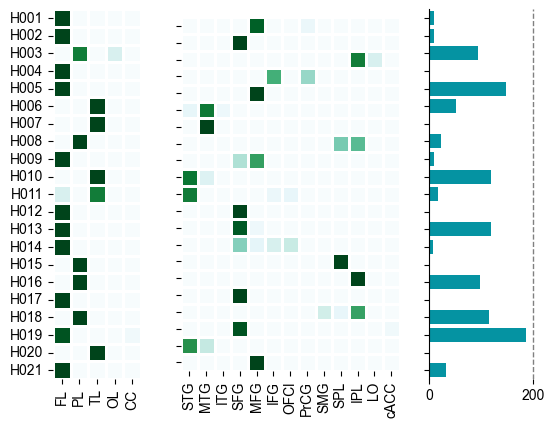

In [31]:
patient_neuron_count = df_ct_human['Patient_Num'].value_counts().sort_index()

fig,axs=plt.subplots(1,3,width_ratios=[1,2,1],sharey=True)

g1=sns.heatmap(pd.DataFrame(htmp_arr_lobe,),square=True,lw=1,vmin=0,vmax=1,cmap='BuGn',ax=axs[0],cbar=False)
g2=sns.heatmap(htmp_arr,square=True,lw=1,vmin=0,vmax=1,cmap='BuGn',ax=axs[1],cbar=False)
axs[1].set_xticklabels([lut_rgn2abbr[x.get_text()] for x in axs[1].get_xticklabels()])
# g3=sns.barplot(y=np.arange(0.5,len(patient_neuron_count)+0.5,1), x=patient_neuron_count.values, orient='h',errorbar=None,ax=axs[1])
for i in range(len(patient_neuron_count)):
    axs[2].barh(y=i+0.5,width=patient_neuron_count.values[i],color=np.array((5,147,162))/255.0,)
axs[2].spines['top'].set_visible(False)
axs[2].spines['right'].set_visible(False)
axs[2].spines['bottom'].set_visible(False)
axs[2].axvline(200, ls='--', color='gray',lw=1)


In [32]:
# only collect full human dataset
# df_sourcedata = pd.concat([htmp_arr_lobe, htmp_arr, patient_neuron_count], axis=1).to_csv(r'E:\ZhixiYun\Projects\fMOST_atlas\Tables\source_data\EDF_human_alignment.csv')


['Precentral'] 12 0.161622061913809
['Superior Frontal'] 334 0.9162094293423935
['Lateral Orbitofrontal', 'Medial Orbitofrontal'] 25 0.14677049854806298
['Supramarginal', 'Superior Parietal', 'Inferior Parietal'] 334 0.9453805529577232
['Superior Parietal'] 141 0.16899447645155508
['Superior Temporal', 'Transverse Temporal'] 191 0.8784388776353835


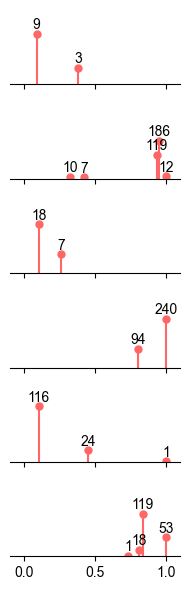

In [33]:
df_m_feature = dict_df_morpho_mouse[50]
df_h_feature = dict_df_morpho_human[50]
df_h_prob = df_ct_human_prob_mat[human_propor_level(2)].copy()

# a special case: H006, subject to the manual labeling
df_h_prob.loc[df_ct_human.index[df_ct_human.Patient_Num=='H006']]=0
df_h_prob.loc[df_ct_human.index[df_ct_human.Patient_Num=='H006'],'Superior Temporal']=1

df_m_prob = pd.get_dummies(df_ct_mouse['CellType'], prefix='', prefix_sep='',dtype=float)

df_m_feature = df_m_feature.loc[df_m_prob.index]
df_h_feature = df_h_feature.loc[df_h_prob.index]

tmpdf = df_h_prob.copy()

count=0
fig,axs = plt.subplots(6,1,figsize=(2,6),tight_layout=True,sharex=True)

source_data_x = []
source_data_y = []
source_data_rgn = []

for i in range(len(func_homo_list)):
    
    neuron_components_notconcat = tmpdf[func_homo_list[i][1]]
    neuron_components = neuron_components_notconcat.sum(axis=1)
    neuron_components = neuron_components[neuron_components!=0]
    neuron_components_vc = neuron_components.value_counts()
    total_neuron = neuron_components_vc.values.sum()
    if total_neuron==0: continue
    
    ax = axs[count]
    ax.set_xlim(0-0.1,1+0.1)
    ax.set_ylim(0,1+0.1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
    
    x = neuron_components_vc.index.values
    y = neuron_components_vc.values/total_neuron
    
    source_data_x.extend(list(x))
    source_data_y.extend(list(y))
    source_data_rgn.extend([func_homo_list[i][1]]*len(x))
    
    markerline, stemline, baseline = ax.stem(x, y, basefmt=" ")
    # plt.setp(stemline, linewidth = 1.25)
    plt.setp(markerline, markersize=5)
    plt.setp(markerline, color=color2)
    plt.setp(stemline, color=color2)
    
    for j in range(len(neuron_components_vc)):
        ax.text(x=neuron_components_vc.index.values[j],y=0.025+neuron_components_vc.values[j]/total_neuron,s=neuron_components_vc.astype(str).values[j],ha='center',va='bottom',)
    # ax.set_title(f'{func_homo_list[i][1]}\n#neuron={total_neuron:d}',fontsize=10)
    print(func_homo_list[i][1], total_neuron, neuron_components.mean())
    count+=1
plt.show()

In [34]:
# df_sourcedata = pd.DataFrame({
#     "prob": source_data_x,
#     "norm_height": source_data_y,
#     "region": source_data_rgn
# })
# df_sourcedata.to_csv(rf'..\Tables\source_data\EDF_lollipop.csv', index=False)

In [35]:
def soft_label_stat(feature, prob):

    def weighted_percentile(values, probabilities, percentile):
        sorted_indices = np.argsort(values)
        sorted_values = values[sorted_indices]
        sorted_probabilities = probabilities[sorted_indices]
        
        cumulative_probabilities = np.cumsum(sorted_probabilities)
        percentile_index = np.searchsorted(cumulative_probabilities, percentile / 100.0)

        # return sorted_values[percentile_index]
        percentile_index = min(percentile_index, len(sorted_values) - 1)
        return sorted_values[percentile_index]
        
    normalized_prob = prob/np.sum(prob)
    fns = feature.columns

    # stat_out = np.zeros((4,feature.shape[1]))
    stat_out = np.zeros((6,feature.shape[1]))

    for i in range(feature.shape[1]):
        avg_col = np.average(feature.values[:,i], weights=normalized_prob.values)
        pct25,pct50,pct75 = [weighted_percentile(feature.values[:,i], normalized_prob.values, x) for x in [25,50,75]]

        iqr = pct75 - pct25
        lower_fence = pct25 - 1.5 * iqr
        upper_fence = pct75 + 1.5 * iqr

        tmp_values = feature.values[:,i]
        tmp_weights = normalized_prob.values

        whisker_mask = (
            (tmp_weights > 0) &
            np.isfinite(tmp_values) &
            (tmp_values >= lower_fence) &
            (tmp_values <= upper_fence)
        )

        if np.sum(whisker_mask) > 0:
            whisker_low = np.min(tmp_values[whisker_mask])
            whisker_high = np.max(tmp_values[whisker_mask])
        else:
            whisker_low = np.nan
            whisker_high = np.nan

        # stat_out[:,i] = [avg_col,pct25,pct50,pct75]
        stat_out[:,i] = [avg_col,pct25,pct50,pct75,whisker_low,whisker_high]
        
    # return pd.DataFrame(stat_out,columns=fns,index=['average','pct25','pct50','pct75'])
    return pd.DataFrame(
        stat_out,
        columns=fns,
        index=['average','pct25','pct50','pct75','whisker_low','whisker_high']
    )


In [36]:
selected_func_homo_list = [
[['PTLp'], ['Superior Parietal']],
    
[['MOs'], ['Superior Frontal']],

[['SSs','PTLp'], ['Supramarginal','Superior Parietal', 'Inferior Parietal']],
    
[['AUDp','AUDd', 'AUDv', 'AUDpo'], ['Superior Temporal', 'Transverse Temporal']],
]


In [37]:
df_m_prob.columns

Index(['AUDd', 'AUDp', 'AUDpo', 'AUDv', 'ECT', 'FRP', 'MOp', 'MOs', 'ORB',
       'PERI', 'PTLp', 'SSp', 'SSs', 'TEa', 'VISC', 'VISpor'],
      dtype='object')

In [38]:
for i, [mfh, hfh] in enumerate(selected_func_homo_list):
    df_m_prob_selected = df_m_prob[mfh].copy()
    df_m_prob_selected = df_m_prob_selected.loc[df_m_prob_selected.sum(axis=1)>0]
    
    df_h_prob_selected = df_h_prob[hfh].copy()
    df_h_prob_selected = df_h_prob_selected.loc[df_h_prob_selected.sum(axis=1)>0]

    print(mfh, hfh)
    print(df_m_prob_selected.shape, df_h_prob_selected.shape)
    

['PTLp'] ['Superior Parietal']
(129, 1) (141, 1)
['MOs'] ['Superior Frontal']
(539, 1) (334, 1)
['SSs', 'PTLp'] ['Supramarginal', 'Superior Parietal', 'Inferior Parietal']
(755, 2) (334, 3)
['AUDp', 'AUDd', 'AUDv', 'AUDpo'] ['Superior Temporal', 'Transverse Temporal']
(422, 4) (191, 2)


['PTLp'] ['Superior Parietal']
['MOs'] ['Superior Frontal']
['SSs', 'PTLp'] ['Supramarginal', 'Superior Parietal', 'Inferior Parietal']
['AUDp', 'AUDd', 'AUDv', 'AUDpo'] ['Superior Temporal', 'Transverse Temporal']


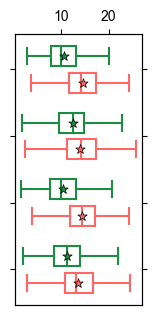

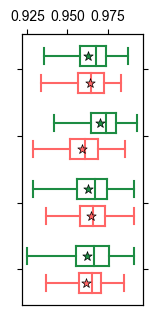

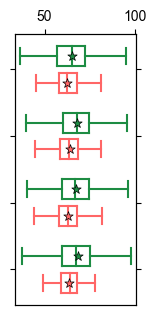

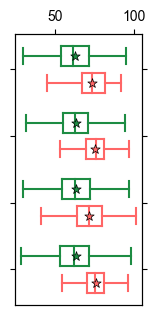

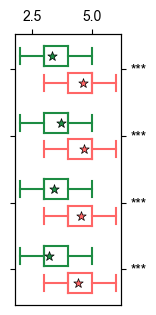

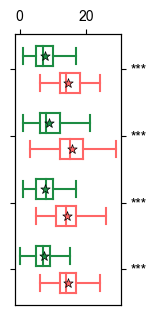

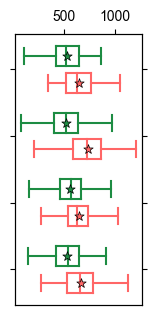

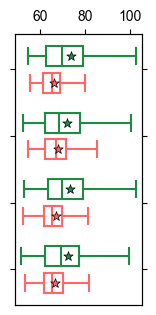

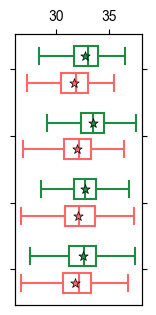

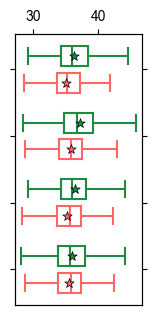

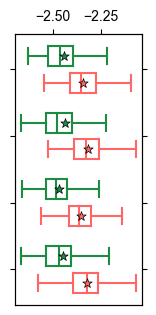

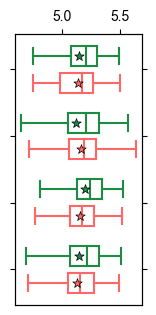

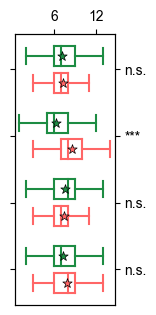

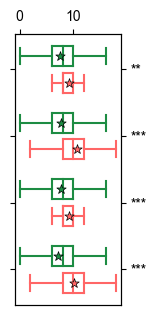

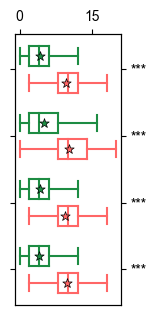

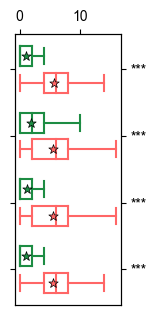

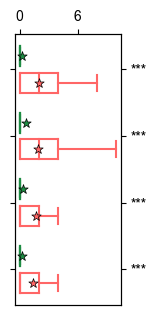

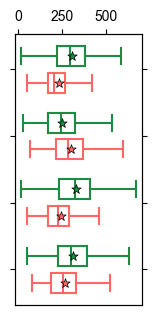

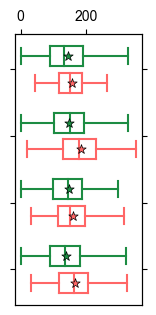

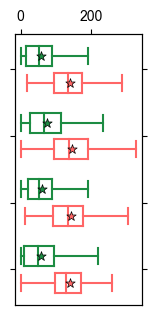

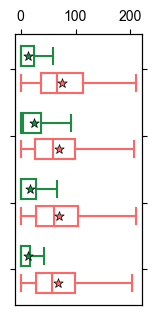

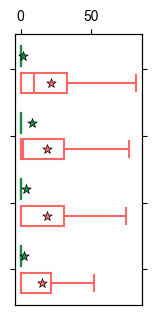

In [39]:
df_sourcedata_list = []

feature_cols = df_m_feature.columns.tolist()

for j in range(df_m_feature.shape[1]):
    tmpfn = df_m_feature.columns[j]
    tmpfeaturevalue = [[], [], []]

    fig, ax = plt.subplots(
        1,
        1,
        figsize=(1.67, 3.25),
        tight_layout=True,
        sharex=True
    )

    stat_significance = []
    count = 0

    for i, [mfh, hfh] in enumerate(selected_func_homo_list):
        df_m_prob_selected = df_m_prob[mfh].sum(axis=1)
        df_h_prob_selected = df_h_prob[hfh].sum(axis=1)

        if np.sum(df_m_prob_selected) == 0 or np.sum(df_h_prob_selected) == 0:
            continue

        if j == 0:
            print(mfh, hfh)

        df_m_stat = soft_label_stat(df_m_feature, df_m_prob_selected)
        df_h_stat = soft_label_stat(df_h_feature, df_h_prob_selected)

        # ---------------------------------------------------------------------
        # Source data for all figures combined
        # One row = region_pair x species x metric
        # Columns = feature columns + region_pair + species + metric
        # Only record once when j == 0, because df_m_stat / df_h_stat already
        # contain all features.
        # ---------------------------------------------------------------------
        if j == 0:
            region_pair = f"{'+'.join(mfh)} | {'+'.join(hfh)}"

            for species, df_stat in zip(
                ['mouse', 'human'],
                [df_m_stat, df_h_stat]
            ):
                df_source_tmp = df_stat.reindex(columns=feature_cols).copy()
                df_source_tmp['region_pair'] = region_pair
                df_source_tmp['species'] = species
                df_source_tmp['metric'] = df_source_tmp.index

                df_source_tmp = df_source_tmp[
                    feature_cols + ['region_pair', 'species', 'metric']
                ]

                df_sourcedata_list.append(df_source_tmp.reset_index(drop=True))

        tmpfeaturevalue[0].extend(
            df_m_feature.iloc[:, j].values[
                df_m_prob_selected.values > 0
            ].tolist()
        )
        tmpfeaturevalue[0].extend(
            df_h_feature.iloc[:, j].values[
                df_h_prob_selected.values > 0
            ].tolist()
        )

        tmpfeaturevalue[1].extend(
            [2 * i] * np.sum(df_m_prob_selected.values > 0)
        )
        tmpfeaturevalue[1].extend(
            [2 * i + 1] * np.sum(df_h_prob_selected.values > 0)
        )

        tmpfeaturevalue[2].extend(
            df_m_prob_selected.values[
                df_m_prob_selected.values > 0
            ].tolist()
        )
        tmpfeaturevalue[2].extend(
            df_h_prob_selected.values[
                df_h_prob_selected.values > 0
            ].tolist()
        )

        # for species,df_stat in zip(['mouse','human'],[df_m_stat,df_h_stat]):
        for species, df_stat in zip(
            ['mouse', 'human'],
            [df_m_stat, df_h_stat]
        ):
            color = color1 if species == 'mouse' else color2
            bias = -0.2 if species == 'mouse' else 0.2
            width = 0.3 / 2

            whisker_low = df_stat.loc[
                'whisker_low',
                df_m_feature.columns[j]
            ]
            whisker_high = df_stat.loc[
                'whisker_high',
                df_m_feature.columns[j]
            ]
            pct25 = df_stat.loc[
                'pct25',
                df_m_feature.columns[j]
            ]
            pct75 = df_stat.loc[
                'pct75',
                df_m_feature.columns[j]
            ]

            cap_width = width * 0.8

            if np.isfinite(whisker_low) and np.isfinite(whisker_high):
                ax.plot(
                    (whisker_low, pct25),
                    (count + bias, count + bias),
                    color=color
                )
                ax.plot(
                    (pct75, whisker_high),
                    (count + bias, count + bias),
                    color=color
                )

                ax.plot(
                    (whisker_low, whisker_low),
                    (count - cap_width + bias, count + cap_width + bias),
                    color=color
                )
                ax.plot(
                    (whisker_high, whisker_high),
                    (count - cap_width + bias, count + cap_width + bias),
                    color=color
                )

            for k in ['pct25', 'pct50', 'pct75']:
                pct = df_stat.loc[k, df_m_feature.columns[j]]
                ax.plot(
                    (pct, pct),
                    (count - width + bias, count + width + bias),
                    color=color
                )

            ax.plot(
                (
                    df_stat.loc['pct25', df_m_feature.columns[j]],
                    df_stat.loc['pct75', df_m_feature.columns[j]]
                ),
                (
                    count - width + bias,
                    count - width + bias
                ),
                color=color
            )
            ax.plot(
                (
                    df_stat.loc['pct25', df_m_feature.columns[j]],
                    df_stat.loc['pct75', df_m_feature.columns[j]]
                ),
                (
                    count + width + bias,
                    count + width + bias
                ),
                color=color
            )

            ax.scatter(
                y=count + bias,
                x=df_stat.loc['average', df_m_feature.columns[j]],
                color=color,
                marker='*',
                edgecolor='black',
                linewidth=0.5,
                s=50,
                zorder=20
            )

        count += 1

    df_forR = pd.DataFrame(
        np.array(tmpfeaturevalue, dtype='object').T,
        columns=['value', 'label', 'weights']
    )

    # df_forR.to_csv(
    #     rf'E:\ZhixiYun\Projects\fMOST_atlas\Tables\forR\{dend_type.rstrip("_")}_magnify\{df_m_feature.columns[j]}.csv'
    # )

    df_R_stat = pd.read_csv(os.path.join(r'E:\ZhixiYun\Projects\fMOST_atlas\Tables\forR',
                                         "pyr_23" if pyr23_only else "",
                                         f"{dend_type.rstrip('_')}_magnify",
                                         "test_results.csv"))
    df_R_stat = df_R_stat[df_R_stat['stat'] == 'MWU']

    ax.tick_params(
        top=True,
        labeltop=True,
        bottom=False,
        labelbottom=False
    )
    ax.invert_yaxis()
    ax.set_title('')
    ax.set_yticks(np.arange(count))
    ax.set_yticklabels([])

    ax_twinx = ax.twinx()
    ax_twinx.yaxis.set_label_position("right")
    ax_twinx.yaxis.tick_right()
    ax_twinx.set_yticks(ax.get_yticks())

    if tmpfn in df_R_stat.columns:
        stat_significance = df_R_stat[tmpfn + '_sig'].values

    ax_twinx.set_yticklabels(stat_significance)
    # ax_twinx.set_ylabel('p-value')
    ax_twinx.set_ylim(ax.get_ylim())

    if tmpfn.find('Branch Num') != -1:
        ax.xaxis.set_major_locator(MaxNLocator(nbins='auto', integer=True))

    # ax.set_xticks(np.arange(count))
    # ax.set_xticklabels([])

    plt.show()


# -----------------------------------------------------------------------------
# Combine source data for all figures
# -----------------------------------------------------------------------------
if len(df_sourcedata_list) > 0:
    df_sourcedata = pd.concat(
        df_sourcedata_list,
        axis=0,
        ignore_index=True
    )
else:
    df_sourcedata = pd.DataFrame(
        columns=feature_cols + ['region_pair', 'species', 'metric']
    )


In [40]:
sourcedata_savepath = r'..\Tables\source_data'
if dend_type == 'apical_':
    keep_cols = ["Bifur Num"] + ["region_pair", "species", "metric"]
    df_sourcedata = df_sourcedata[keep_cols]
    # if pyr23_only:
    #     df_sourcedata.to_csv(os.path.join(sourcedata_savepath, 'Fig_5C_EDF_pyr23_apical_magnify.csv'), index=False)
    # else:
    #     df_sourcedata.to_csv(os.path.join(sourcedata_savepath, 'Fig_5C_apical_magnify.csv'), index=False)
                
elif dend_type == 'basal_':
    keep_cols = ["Bifur Num", "Max Branch Order"] + [f"L{x} Branch Num" for x in range(1, 6)] + ["region_pair", "species", "metric"]
    df_sourcedata = df_sourcedata[keep_cols]
    # if pyr23_only:
    #     df_sourcedata.to_csv(os.path.join(sourcedata_savepath, 'Fig_5C_EDF_pyr23_basal_magnify.csv'), index=False)
    # else:
    #     df_sourcedata.to_csv(os.path.join(sourcedata_savepath, 'Fig_5C_basal_magnify.csv'), index=False)

